# Linear Systems, Curve Fitting, and Interpolation Methods

Numerical methods for two related problems: solving linear systems of equations (Gauss elimination, Gauss-Jordan, Gauss-Seidel, matrix inversion and determinants via cofactor expansion, LU factorization, Gram-Schmidt orthogonalization) and fitting/interpolating tabulated data (Taylor, Lagrange, and Newton interpolating polynomials; least-squares regression for linear, exponential, and power-law models; and a Newton divided-differences interpolant applied to a real atmospheric pressure-vs-altitude dataset).

## Part 1: Linear Systems of Equations

**1.** Solve the following system of equations using Gauss elimination:

$$
\begin{aligned}
a+b+2c-d+e-3f &= 4\\
a-b+c+3d-3e+f &= -2\\
a-c+4d-5e &= 8\\
-a+b+c+d-2f &= 8\\
a-b-c+2d-e+2f &= 0\\
2a+b+2c-d-e-f &= -2
\end{aligned}
$$

In [13]:
# Import required libraries
import numpy as np

# Ask for the number of variables
n = int(input("Number of variables: "))

# Initialize the augmented matrix and solution vector
aug_matrix = [[0 for col in range(n + 1)] for row in range(n)]
solution = [0 for _ in range(n)]

# Fill the augmented matrix with user-provided values
for i in range(n):
    for j in range(n + 1):
        aug_matrix[i][j] = float(input(f"Entry ({i+1}, {j+1}): "))

# Show the initial augmented matrix
print("\nInitial augmented matrix:")
for row in aug_matrix:
    print(row)

# Gaussian elimination
for i in range(n - 1):
    for j in range(i + 1, n):
        factor = aug_matrix[j][i] / aug_matrix[i][i]
        for k in range(n + 1):
            aug_matrix[j][k] -= factor * aug_matrix[i][k]

# Show the augmented matrix after elimination
print("\nAugmented matrix after Gaussian elimination:")
for row in aug_matrix:
    print(row)

# Back-substitution
solution[n - 1] = aug_matrix[n - 1][n] / aug_matrix[n - 1][n - 1]

for i in range(n - 2, -1, -1):
    s = 0
    for j in range(n - 1, i, -1):
        s += aug_matrix[i][j] * solution[j]
    solution[i] = (aug_matrix[i][n] - s) / aug_matrix[i][i]

# Show the final solution
print("\nSolution vector:")
for idx, val in enumerate(solution):
    print(f"x{idx+1} = {val:.6f}")



Matriz extendida inicial:
[1.0, 1.0, 2.0, -1.0, 1.0, -3.0, 4.0]
[1.0, -1.0, 1.0, 3.0, -3.0, 1.0, -2.0]
[1.0, 0.0, -1.0, 4.0, -5.0, 0.0, 8.0]
[-1.0, 1.0, 1.0, 1.0, 0.0, -2.0, 8.0]
[1.0, -1.0, -1.0, 2.0, -1.0, 2.0, 0.0]
[2.0, 1.0, 2.0, -1.0, -1.0, -1.0, -2.0]

Matriz extendida después de la reducción gaussiana:
[1.0, 1.0, 2.0, -1.0, 1.0, -3.0, 4.0]
[0.0, -2.0, -1.0, 4.0, -4.0, 4.0, -6.0]
[0.0, 0.0, -2.5, 3.0, -4.0, 1.0, 7.0]
[0.0, 0.0, 0.0, 6.4, -6.2, -0.19999999999999996, 11.600000000000001]
[0.0, 0.0, 0.0, 0.0, 1.90625, 0.09374999999999997, 2.5625]
[0.0, 0.0, 0.0, 0.0, 0.0, 2.3770491803278686, -4.360655737704917]

Vector solución:
x1 = 0.537931
x2 = 3.779310
x3 = -2.055172
x4 = 3.144828
x5 = 1.434483
x6 = -1.834483


**2.** Solve the following system using Gauss-Jordan elimination:

$$
\begin{aligned}
-2x_2-3x_3+12x_4-8x_5+21x_6 &= 6.1\\
2x_1+4x_2-9x_5 &= 14.5\\
3x_2-5x_4+8x_6 &= -12.1\\
x_2-11x_4+7x_5-8x_6 &= 3.7\\
3x_1+2x_2+3x_3-4x_4-8x_5-6x_6 &= 7.8\\
-9x_1+3x_2-9x_6 &= -4.2
\end{aligned}
$$

In [15]:
import numpy as np

# Ask for the number of variables
n = int(input("Number of variables: "))

# Initialize the augmented matrix (original matrix A + vector b + identity)
aug_matrix = [[0 for col in range(2 * n + 1)] for row in range(n)]

# Fill matrix A with user-provided coefficients
for i in range(n):
    for j in range(n):
        aug_matrix[i][j] = float(input(f"Coefficient A({i+1},{j+1}): "))

# Fill vector b (last column before the identity block)
for i in range(n):
    aug_matrix[i][n] = float(input(f"Right-hand side b({i+1}): "))

# Append the identity matrix to the right of the augmented matrix
for i in range(n):
    aug_matrix[i][n + 1 + i] = 1.0

# Show the initial augmented matrix with A, b, and the identity
print("\nInitial augmented matrix (A | b | Identity):")
for row in aug_matrix:
    print(row)

# Gauss-Jordan elimination with partial pivoting
for i in range(n):
    # Partial pivoting: swap rows if the pivot is zero
    if aug_matrix[i][i] == 0:
        for k in range(i + 1, n):
            if aug_matrix[k][i] != 0:
                aug_matrix[i], aug_matrix[k] = aug_matrix[k], aug_matrix[i]
                break

    # Check whether the system is singular after pivoting
    if aug_matrix[i][i] == 0:
        print("\nThe system is singular and has no unique solution.")
        exit()

    # Normalize the row by dividing by the pivot
    pivot = aug_matrix[i][i]
    for j in range(2 * n + 1):
        aug_matrix[i][j] /= pivot

    # Zero out every other row in this column
    for j in range(n):
        if i != j:
            factor = aug_matrix[j][i]
            for k in range(2 * n + 1):
                aug_matrix[j][k] -= factor * aug_matrix[i][k]

# Show the transformed matrix (identity | solution vector x | inverse)
print("\nTransformed matrix (Identity | Solution vector x | Inverse):")
for row in aug_matrix:
    print(row)

# Extract the inverse matrix from the right-hand block
inverse_matrix = [[aug_matrix[i][j] for j in range(n + 1, 2 * n + 1)] for i in range(n)]

# Extract the solution vector x (column n, formerly b)
solution_vector = [aug_matrix[i][n] for i in range(n)]

# Show the obtained inverse matrix
print("\nObtained inverse matrix:")
for row in inverse_matrix:
    print(row)

# Show the solution vector x
print("\nSolution vector x:")
for i, val in enumerate(solution_vector):
    print(f"x{i+1} = {val:.6f}")



Matriz extendida inicial (A | b | Identidad):
[0.0, -2.0, -3.0, 12.0, -8.0, 21.0, 6.1, 1.0, 0, 0, 0, 0, 0]
[2.0, 4.0, 0.0, 0.0, -9.0, 0.0, 14.5, 0, 1.0, 0, 0, 0, 0]
[0.0, 3.0, 0.0, -5.0, 0.0, 8.0, -12.1, 0, 0, 1.0, 0, 0, 0]
[0.0, 1.0, 0.0, -11.0, 7.0, -8.0, 3.7, 0, 0, 0, 1.0, 0, 0]
[3.0, 2.0, 3.0, -4.0, -8.0, -6.0, 7.8, 0, 0, 0, 0, 1.0, 0]
[-9.0, 3.0, 0.0, 0.0, 0.0, -9.0, -4.2, 0, 0, 0, 0, 0, 1.0]

Matriz transformada (Identidad | Vector solución x | Inversa ):
[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9289505211453175, -0.0891338205343235, 0.11471187252905213, -0.01886905475020928, -0.0562477536839584, -0.0891338205343235, -0.11533085739387405]
[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -2.569198514436322, -0.21959985623577344, 0.21205223433568965, 0.15310890140170103, -0.22930394153588118, -0.21959985623577344, -0.02607723333732679]
[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -7.686184657162255, -0.1873727087576375, -0.2454175152749491, 0.2318397827562798, -0.3628649015614393, 0.1459606245756958, -0.0058836840914234

**3.** Solve the following system using Gauss-Seidel iteration, with proposed error tolerances of $10^{-2}$ and $10^{-6}$, and evaluate the resulting roots back in the system to compare the discrepancy between results.

$$
\begin{aligned}
17x_1-2x_2-3x_3 &= 500\\
-5x_1+21x_2-2x_3 &= 200\\
-5x_1-5x_2+22x_3 &= 30
\end{aligned}
$$

In [5]:
import numpy as np

# Ask for the number of unknowns
n = int(input("Number of variables: "))
error_tol_1 = 1e-6
error_tol_2 = 1e-2
iteration = 0
max_iter = 1000
count = 0
error_count = 0

# Create the augmented matrix and vectors
aug_matrix = np.zeros((n, n + 1))
error_vector = np.ones(n)
x_curr = np.zeros(n)
x_prev = np.ones(n)

# Ask for the coefficients
print("Enter the coefficients of matrix A and vector b:")
for i in range(n):
    for j in range(n + 1):
        aug_matrix[i, j] = float(input(f"Entry [{i+1},{j+1}]: "))
    x_prev[i] = aug_matrix[i, n] / aug_matrix[i, i]

# Check the convergence criterion
def check_convergence(aug_matrix, n):
    count = 0
    for i in range(n):
        row_sum = sum(abs(aug_matrix[i, j]) for j in range(n) if i != j)
        if abs(row_sum) < abs(aug_matrix[i, i]):
            count += 1
    return count == n

converges = check_convergence(aug_matrix, n)

def gauss_seidel(aug_matrix, n, error_tol):
    x_prev = np.ones(n)
    x_curr = np.copy(x_prev)
    error_vector = np.ones(n)
    iteration = 0
    error_count = 0

    while converges and error_count < n and iteration < max_iter:
        for i in range(n):
            s = sum(aug_matrix[i, j] * x_curr[j] for j in range(n) if i != j)
            x_curr[i] = (aug_matrix[i, n] - s) / aug_matrix[i, i]

        error_count = sum(1 for i in range(n) if abs((x_curr[i] - x_prev[i]) / x_curr[i]) < error_tol)
        error_vector = [abs((x_curr[i] - x_prev[i]) / x_curr[i]) for i in range(n)]
        iteration += 1
        x_prev = np.copy(x_curr)

    return x_curr, iteration, error_vector

def evaluate_solution(aug_matrix, x, n):
    return [sum(aug_matrix[i, j] * x[j] for j in range(n)) for i in range(n)]

# Solve with error tolerance 10^-6
sol1, iter1, err1 = gauss_seidel(aug_matrix, n, error_tol_1)
eval1 = evaluate_solution(aug_matrix, sol1, n)
print("\nResults for error tolerance 10^-6:")
print("Solution found:", sol1.tolist())
print("Iterations performed:", iter1)
print("Error vector:", err1)
print("Evaluation vector:", eval1)

# Solve with error tolerance 10^-2
sol2, iter2, err2 = gauss_seidel(aug_matrix, n, error_tol_2)
eval2 = evaluate_solution(aug_matrix, sol2, n)
print("\nResults for error tolerance 10^-2:")
print("Solution found:", sol2.tolist())
print("Iterations performed:", iter2)
print("Error vector:", err2)
print("Evaluation vector:", eval2)


Introduce los coeficientes de la matriz A y el vector b:

Resultados para error de 10^-6:
Solución encontrada: [33.9963125630889, 18.892825957738705, 13.383895118369908]
Iteraciones realizadas: 8
Vector de errores: [np.float64(3.404190673845164e-07), np.float64(3.119853187322693e-07), np.float64(2.9661288620137885e-07)]
Vector de evaluación: [np.float64(499.9999763019241), np.float64(199.99999206032848), np.float64(30.0)]

Resultados para error de 10^-2:
Solución encontrada: [33.988785080784744, 18.888992257573864, 13.381313031445137]
Iteraciones realizadas: 4
Vector de errores: [np.float64(0.001617234984965561), np.float64(0.0014825076090490819), np.float64(0.001409206169611626)]
Vector de evaluación: [np.float64(499.8874227638575), np.float64(199.96228594223717), np.float64(30.0)]


**4.** For each of the following matrices, compute the determinant and the inverse (if it exists), and additionally find an LU factorization.

Recall that a matrix has an inverse iff its determinant is nonzero, i.e. $\det \neq 0 \iff$ inverse exists.

$$
a)\quad
\begin{pmatrix}
1 & 1 & 1 & 1 & 1 & 1\\
-6 & 7 & 0 & 0 & -5 & 2\\
7 & 8 & 7 & 0 & -9 & 2\\
5 & 4 & 3 & 0 & 9 & 1\\
6 & 5 & 5 & 4 & 3 & 8\\
2 & 1 & 1 & 6 & -8 & 2
\end{pmatrix}
$$

In [13]:
def get_minor(matrix, i, j):
    # removes row i and column j to build the minor
    return [row[:j] + row[j+1:] for k, row in enumerate(matrix) if k != i]

def determinant(matrix):
    n = len(matrix)

    # base case: 1x1 matrix
    if n == 1:
        return matrix[0][0]

    # base case: 2x2 matrix
    if n == 2:
        return matrix[0][0]*matrix[1][1] - matrix[0][1]*matrix[1][0]

    det = 0
    for j in range(n):
        sign = (-1) ** j  # alternating sign
        minor = get_minor(matrix, 0, j)
        det += sign * matrix[0][j] * determinant(minor)

    return det

matrix = [
    [1, 1, 1, 1, 1, 1],
    [-6, 7, 0, 0, -5, 2],
    [7, 8, 7, 0, -9, 2],
    [5, 4, 3, 0, 9, 1],
    [6, 5, 5, 4, 3, 8],
    [2, 1, 1, 6, -8, 2]
]

print("Determinant:", determinant(matrix))


Determinante: -14599


Since the determinant is nonzero, the inverse exists; proceeding to compute it and its LU factorization.

In [10]:
# Ask for the number of variables
n = int(input("Number of variables: "))

# Build an augmented n x 2n matrix (A | I)
aug_matrix = [[0 for _ in range(2 * n)] for _ in range(n)]

# Fill matrix A (left half of the augmented matrix)
print("Enter the coefficients of matrix A:")
for i in range(n):
    for j in range(n):
        aug_matrix[i][j] = float(input(f"A({i+1},{j+1}): "))

# Append the identity matrix (right half)
for i in range(n):
    aug_matrix[i][n + i] = 1.0

# Show the initial augmented matrix
print("\nInitial augmented matrix (A | Identity):")
for row in aug_matrix:
    print([round(x, 3) for x in row])

# Gauss-Jordan elimination to obtain the inverse
for i in range(n):
    # Partial pivoting if the pivot is zero
    if aug_matrix[i][i] == 0:
        for k in range(i + 1, n):
            if aug_matrix[k][i] != 0:
                aug_matrix[i], aug_matrix[k] = aug_matrix[k], aug_matrix[i]
                break

    # Check whether the matrix is singular
    if aug_matrix[i][i] == 0:
        print("\nThe matrix is singular and has no inverse.")
        exit()

    # Normalize row i by dividing by the pivot
    pivot = aug_matrix[i][i]
    for j in range(2 * n):
        aug_matrix[i][j] /= pivot

    # Zero out the other rows
    for j in range(n):
        if i != j:
            factor = aug_matrix[j][i]
            for k in range(2 * n):
                aug_matrix[j][k] -= factor * aug_matrix[i][k]

# Extract the inverse matrix from the right-hand block
inverse_matrix = [[aug_matrix[i][j] for j in range(n, 2 * n)] for i in range(n)]

# Show the inverse matrix
print("\nObtained inverse matrix:")
for row in inverse_matrix:
    print([round(x, 6) for x in row])


Ingresa los coeficientes de la matriz A:

Matriz extendida inicial (A | Identidad):
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0, 0, 0, 0, 0]
[-6.0, 7.0, 0.0, 0.0, -5.0, 2.0, 0, 1.0, 0, 0, 0, 0]
[7.0, 8.0, 7.0, 0.0, -9.0, 2.0, 0, 0, 1.0, 0, 0, 0]
[5.0, 4.0, 3.0, 0.0, 9.0, 1.0, 0, 0, 0, 1.0, 0, 0]
[6.0, 5.0, 5.0, 4.0, 3.0, 8.0, 0, 0, 0, 0, 1.0, 0]
[2.0, 1.0, 1.0, 6.0, -8.0, 2.0, 0, 0, 0, 0, 0, 1.0]

Matriz inversa obtenida:
[-1.50298, -0.034865, -0.005274, 0.249332, 0.12494, 0.167203]
[-0.879649, 0.109391, -0.01685, 0.251113, 0.022536, 0.131584]
[3.077471, -0.0935, 0.137133, -0.482636, -0.248442, -0.347284]
[0.751901, 0.005, -0.048359, 0.013357, -0.114186, 0.117474]
[0.280978, 0.000411, -0.031372, 0.028495, -0.023084, -0.031441]
[-0.727721, 0.013563, -0.035276, -0.059662, 0.238235, -0.037537]


In [11]:
# LU factorization without partial pivoting, using explicit L and U matrices

# Ask for the number of variables (dimension of the square matrix A)
n = int(input("Number of variables (n x n): "))

# Initialize L, U, and the L*U product with zeros
matrix_U = []  # upper-triangular matrix
matrix_L = []  # lower-triangular matrix (with 1s on the diagonal)
product_LU = []  # matrix to verify L * U = A

for row in range(n):
    zero_row = [0] * n
    matrix_U.append(zero_row[:])
    matrix_L.append(zero_row[:])
    product_LU.append(zero_row[:])
    matrix_L[row][row] = 1  # L has 1s on the diagonal

# Enter the entries of matrix A to be factorized
print("\nEnter the entries of matrix A (to be factorized into L and U):")
for i in range(n):
    for j in range(n):
        matrix_U[i][j] = float(input(f"A({i+1},{j+1}): "))

# Show the original matrix A (stored in U before being transformed)
print("\nOriginal matrix A (stored in U before modification):")
for row in matrix_U:
    print(row)

# LU factorization process (no pivoting)
for pivot in range(n - 1):  # walk the main diagonal
    for row in range(pivot + 1, n):  # rows below the pivot
        factor = matrix_U[row][pivot] / matrix_U[pivot][pivot]
        matrix_L[row][pivot] = factor  # store factor in L
        for col in range(n):
            matrix_U[row][col] -= factor * matrix_U[pivot][col]

# Show the resulting L and U matrices
print("\nMatrix L (lower triangular):")
for row in matrix_L:
    print([round(elem, 6) for elem in row])

print("\nMatrix U (upper triangular):")
for row in matrix_U:
    print([round(elem, 6) for elem in row])

# Verify that L * U = A (matrix product)
for i in range(n):
    for j in range(n):
        s = 0
        for k in range(n):
            s += matrix_L[i][k] * matrix_U[k][j]
        product_LU[i][j] = s

# Show the L * U product
print("\nVerification of the L * U product (should equal the original matrix A):")
for row in product_LU:
    print([round(elem, 6) for elem in row])



Ingresa los elementos de la matriz A (a factorizar en L y U):

Matriz A original (guardada en U antes de modificarla):
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[-6.0, 7.0, 0.0, 0.0, -5.0, 2.0]
[7.0, 8.0, 7.0, 0.0, -9.0, 2.0]
[5.0, 4.0, 3.0, 0.0, 9.0, 1.0]
[6.0, 5.0, 5.0, 4.0, 3.0, 8.0]
[2.0, 1.0, 1.0, 6.0, -8.0, 2.0]

Matriz L (triangular inferior):
[1, 0, 0, 0, 0, 0]
[-6.0, 1, 0, 0, 0, 0]
[7.0, 0.076923, 1, 0, 0, 0]
[5.0, -0.076923, 3.333333, 1, 0, 0]
[6.0, -0.076923, 1.166667, 0.352459, 1, 0]
[2.0, -0.076923, 1.166667, 0.647541, 6.346715, 1]

Matriz U (triangular superior):
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 13.0, 6.0, 6.0, 1.0, 8.0]
[0.0, 0.0, -0.461538, -7.461538, -16.076923, -5.615385]
[0.0, 0.0, 0.0, 20.333333, 57.666667, 15.333333]
[0.0, 0.0, 0.0, 0.0, -4.491803, 3.762295]
[0.0, 0.0, 0.0, 0.0, 0.0, -26.640511]

Verificación del producto L * U (debe ser igual a la matriz A original):
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[-6.0, 7.0, 0.0, 0.0, -5.0, 2.0]
[7.0, 8.0, 7.0, 0.0, -9.0, 2.0]
[5.0, 4.

$$
b)\quad
\begin{pmatrix}
2 & -1 & -6 & 3 & 5 & 7 & -9 & 0\\
1 & 5 & 5 & -1 & 1 & 1 & -1 & 5\\
2 & 0 & 4 & 7 & 0 & 0 & 0 & 2\\
4 & 0 & 5 & -6 & 3 & 5 & -1 & 2\\
1 & -2 & 0 & -4 & 2 & 10 & -1 & 1\\
10 & 3 & 1 & 1 & 0 & 0 & -2 & 8\\
2 & -7 & 0 & -4 & 6 & 8 & 3 & 1\\
4 & 3 & 10 & -9 & -9 & 4 & 5 & 1
\end{pmatrix}
$$

In [17]:
def get_minor(matrix, i, j):
    # removes row i and column j to build the minor
    return [row[:j] + row[j+1:] for k, row in enumerate(matrix) if k != i]

def determinant(matrix):
    n = len(matrix)

    # base case: 1x1 matrix
    if n == 1:
        return matrix[0][0]

    # base case: 2x2 matrix
    if n == 2:
        return matrix[0][0]*matrix[1][1] - matrix[0][1]*matrix[1][0]

    det = 0
    for j in range(n):
        sign = (-1) ** j  # alternating sign
        minor = get_minor(matrix, 0, j)
        det += sign * matrix[0][j] * determinant(minor)

    return det

matrix = [
    [2, -1, -6, 3, 5, 7, -9, 0],
    [1, 5, 5, -1, 1, 1, -1, 5],
    [2, 0 , 4, 7, 0 , 0 , 0, 2],
    [4, 0, 5, -6, 3, 5, -1, 2],
    [1, -2, 0, -4, 2, 10, -1, 1],
    [10, 3, 1, 1, 0, 0, -2, 8],
    [2, -7, 0, -4, 6, 8, 3, 1],
    [4, 3, 10, -9, -9, 4, 5, 1]
]

print("Determinant:", determinant(matrix))


Determinante: -9738


Since the determinant is nonzero, proceeding to compute the inverse and the LU factorization.

In [15]:
# Ask for the number of variables
n = int(input("Number of variables: "))

# Build an augmented n x 2n matrix (A | I)
aug_matrix = [[0 for _ in range(2 * n)] for _ in range(n)]

# Fill matrix A (left half of the augmented matrix)
print("Enter the coefficients of matrix A:")
for i in range(n):
    for j in range(n):
        aug_matrix[i][j] = float(input(f"A({i+1},{j+1}): "))

# Append the identity matrix (right half)
for i in range(n):
    aug_matrix[i][n + i] = 1.0

# Show the initial augmented matrix
print("\nInitial augmented matrix (A | Identity):")
for row in aug_matrix:
    print([round(x, 3) for x in row])

# Gauss-Jordan elimination to obtain the inverse
for i in range(n):
    # Partial pivoting if the pivot is zero
    if aug_matrix[i][i] == 0:
        for k in range(i + 1, n):
            if aug_matrix[k][i] != 0:
                aug_matrix[i], aug_matrix[k] = aug_matrix[k], aug_matrix[i]
                break

    # Check whether the matrix is singular
    if aug_matrix[i][i] == 0:
        print("\nThe matrix is singular and has no inverse.")
        exit()

    # Normalize row i by dividing by the pivot
    pivot = aug_matrix[i][i]
    for j in range(2 * n):
        aug_matrix[i][j] /= pivot

    # Zero out the other rows
    for j in range(n):
        if i != j:
            factor = aug_matrix[j][i]
            for k in range(2 * n):
                aug_matrix[j][k] -= factor * aug_matrix[i][k]

# Extract the inverse matrix from the right-hand block
inverse_matrix = [[aug_matrix[i][j] for j in range(n, 2 * n)] for i in range(n)]

# Show the inverse matrix
print("\nObtained inverse matrix:")
for row in inverse_matrix:
    print([round(x, 6) for x in row])


Ingresa los coeficientes de la matriz A:

Matriz extendida inicial (A | Identidad):
[2.0, -1.0, -6.0, 3.0, 5.0, 7.0, -9.0, 0.0, 1.0, 0, 0, 0, 0, 0, 0, 0]
[1.0, 5.0, 5.0, -1.0, 1.0, 1.0, -1.0, 5.0, 0, 1.0, 0, 0, 0, 0, 0, 0]
[2.0, 0.0, 4.0, 7.0, 0.0, 0.0, 0.0, 2.0, 0, 0, 1.0, 0, 0, 0, 0, 0]
[4.0, 0.0, 5.0, -6.0, 3.0, 5.0, -1.0, 2.0, 0, 0, 0, 1.0, 0, 0, 0, 0]
[1.0, -2.0, 0.0, -4.0, 2.0, 10.0, -1.0, 1.0, 0, 0, 0, 0, 1.0, 0, 0, 0]
[10.0, 3.0, 1.0, 1.0, 0.0, 0.0, -2.0, 8.0, 0, 0, 0, 0, 0, 1.0, 0, 0]
[2.0, -7.0, 0.0, -4.0, 6.0, 8.0, 3.0, 1.0, 0, 0, 0, 0, 0, 0, 1.0, 0]
[4.0, 3.0, 10.0, -9.0, -9.0, 4.0, 5.0, 1.0, 0, 0, 0, 0, 0, 0, 0, 1.0]

Matriz inversa obtenida:
[-97.230129, -77.136784, 26.909427, 78.963956, 148.414048, 25.243068, -103.881701, -72.539741]
[-192.957794, -152.763401, 53.321832, 156.511296, 294.608133, 49.959437, -206.159581, -143.9733]
[48.589341, 38.49353, -13.35038, -39.310639, -74.22366, -12.634525, 51.888478, 36.265763]
[-44.746149, -35.452865, 12.473403, 36.255289, 68.3438

In [18]:
# LU factorization without partial pivoting, using explicit L and U matrices

# Ask for the number of variables (dimension of the square matrix A)
n = int(input("Number of variables (n x n): "))

# Initialize L, U, and the L*U product with zeros
matrix_U = []  # upper-triangular matrix
matrix_L = []  # lower-triangular matrix (with 1s on the diagonal)
product_LU = []  # matrix to verify L * U = A

for row in range(n):
    zero_row = [0] * n
    matrix_U.append(zero_row[:])
    matrix_L.append(zero_row[:])
    product_LU.append(zero_row[:])
    matrix_L[row][row] = 1  # L has 1s on the diagonal

# Enter the entries of matrix A to be factorized
print("\nEnter the entries of matrix A (to be factorized into L and U):")
for i in range(n):
    for j in range(n):
        matrix_U[i][j] = float(input(f"A({i+1},{j+1}): "))

# Show the original matrix A (stored in U before being transformed)
print("\nOriginal matrix A (stored in U before modification):")
for row in matrix_U:
    print(row)

# LU factorization process (no pivoting)
for pivot in range(n - 1):  # walk the main diagonal
    for row in range(pivot + 1, n):  # rows below the pivot
        factor = matrix_U[row][pivot] / matrix_U[pivot][pivot]
        matrix_L[row][pivot] = factor  # store factor in L
        for col in range(n):
            matrix_U[row][col] -= factor * matrix_U[pivot][col]

# Show the resulting L and U matrices
print("\nMatrix L (lower triangular):")
for row in matrix_L:
    print([round(elem, 6) for elem in row])

print("\nMatrix U (upper triangular):")
for row in matrix_U:
    print([round(elem, 6) for elem in row])

# Verify that L * U = A (matrix product)
for i in range(n):
    for j in range(n):
        s = 0
        for k in range(n):
            s += matrix_L[i][k] * matrix_U[k][j]
        product_LU[i][j] = s

# Show the L * U product
print("\nVerification of the L * U product (should equal the original matrix A):")
for row in product_LU:
    print([round(elem, 6) for elem in row])



Ingresa los elementos de la matriz A (a factorizar en L y U):

Matriz A original (guardada en U antes de modificarla):
[2.0, -1.0, -6.0, 3.0, 5.0, 7.0, -9.0, 0.0]
[1.0, 5.0, 5.0, -1.0, 1.0, 1.0, -1.0, 5.0]
[2.0, 0.0, 4.0, 7.0, 0.0, 0.0, 0.0, 2.0]
[4.0, 0.0, 5.0, -6.0, 3.0, 5.0, -1.0, 2.0]
[1.0, -2.0, 0.0, -4.0, 2.0, 10.0, -1.0, 1.0]
[10.0, 3.0, 1.0, 1.0, 0.0, 0.0, -2.0, 8.0]
[2.0, -7.0, 0.0, -4.0, 6.0, 8.0, 3.0, 1.0]
[4.0, 3.0, 10.0, -9.0, -9.0, 4.0, 5.0, 1.0]

Matriz L (triangular inferior):
[1, 0, 0, 0, 0, 0, 0, 0]
[0.5, 1, 0, 0, 0, 0, 0, 0]
[1.0, 0.181818, 1, 0, 0, 0, 0, 0]
[2.0, 0.363636, 1.648936, 1, 0, 0, 0, 0]
[0.5, -0.272727, 0.606383, 0.481823, 1, 0, 0, 0]
[5.0, 1.454545, 2.265957, 1.109636, -10.364276, 1, 0, 0]
[1.0, -1.090909, 1.723404, 0.944028, 4.761549, -0.488219, 1, 0]
[2.0, 0.909091, 1.723404, 1.106751, -8.366036, 1.045857, -1.432275, 1]

Matriz U (triangular superior):
[2.0, -1.0, -6.0, 3.0, 5.0, 7.0, -9.0, 0.0]
[0.0, 5.5, 8.0, -2.5, -1.5, -2.5, 3.5, 5.0]
[0.0, 0.0, 8

**5.** Using the Gram-Schmidt algorithm, determine the set of ORTHONORMAL vectors (if any!) for the vector subspace described by each of the following vector sets:

$$
\begin{aligned}
A)\quad & B = \{ (1,0,1),\ (0,0,1),\ (-1,1,0) \}\\
B)\quad & B = \{ (1,0,1,0),\ (3,1,2,1),\ (-1,-3,2,5),\ (2,1,-2,4) \}\\
C)\quad & B = \{ (5/13,0,12/13,13/15),\ (1/4,1,0,-1),\ (-1/13,0,5/13,0) \}
\end{aligned}
$$

**A)**

In [19]:
# Gram-Schmidt orthogonalization (matrix form)
# Input: n vectors of dimension n

# Ask for the number of vectors (and their dimension)
n = int(input("Number of vectors (and their dimension): "))

# Initialize matrices
vector_matrix = []      # original matrix with the vectors as rows
vector_transpose = []   # transpose of the original matrix
dot_product = []        # dot-product matrix: V * V^T
aug_matrix = []         # augmented matrix for reduction: [dot_product | vector_matrix]

# Create zero-filled matrices
for i in range(n):
    zero_row = [0] * n
    vector_matrix.append(zero_row[:])
    vector_transpose.append(zero_row[:])
    dot_product.append(zero_row[:])

    ext_row = [0] * (2 * n)
    aug_matrix.append(ext_row)

# Ask for the vectors
print("\n--- Vector input ---")
for i in range(n):
    for j in range(n):
        vector_matrix[i][j] = float(input(f"Vector {i+1}, component {j+1}: "))

# Show the original matrix
print("\n--- Original matrix (vectors as rows) ---")
for row in vector_matrix:
    print(row)

# Compute the transpose
for i in range(n):
    for j in range(n):
        vector_transpose[i][j] = vector_matrix[j][i]

# Show the transpose
print("\n--- Transpose of the original matrix ---")
for row in vector_transpose:
    print(row)

# Compute the dot product: V * V^T
for i in range(n):
    for j in range(n):
        s = 0
        for k in range(n):
            s += vector_matrix[i][k] * vector_transpose[k][j]
        dot_product[i][j] = s

# Show the dot-product matrix
print("\n--- Dot-product matrix V * V^T ---")
for row in dot_product:
    print(row)

# Build the augmented matrix: [dot_product | vector_matrix]
for i in range(n):
    for j in range(n):
        aug_matrix[i][j] = dot_product[i][j]
        aug_matrix[i][j + n] = vector_matrix[i][j]

# Show the augmented matrix before reduction
print("\n--- Augmented matrix before reduction ---")
for row in aug_matrix:
    print(row)

# Apply Gaussian elimination to diagonalize the left block (dot product)
for pivot in range(n - 1):
    for row in range(pivot + 1, n):
        factor = aug_matrix[row][pivot] / aug_matrix[pivot][pivot]
        for col in range(2 * n):
            aug_matrix[row][col] -= factor * aug_matrix[pivot][col]

# Show the augmented matrix after elimination
print("\n--- Augmented matrix after Gauss-type elimination ---")
for row in aug_matrix:
    print([round(elem, 6) for elem in row])

# Normalize the rows of the right block (which now holds the orthogonal vectors)
for i in range(n):
    divisor = aug_matrix[i][i]  # diagonal entry
    for j in range(n):
        aug_matrix[i][j + n] /= divisor

# Show the final matrix with the orthonormal vectors
print("\n--- Orthonormal vectors (result of the Gram-Schmidt process) ---")
for i in range(n):
    print([round(elem, 6) for elem in aug_matrix[i][n:]])



--- Ingreso de vectores ---

--- Matriz original (vectores como filas) ---
[1.0, 0.0, 1.0]
[0.0, 0.0, 1.0]
[-1.0, 1.0, 0.0]

--- Transpuesta de la matriz original ---
[1.0, 0.0, -1.0]
[0.0, 0.0, 1.0]
[1.0, 1.0, 0.0]

--- Matriz de producto punto V * V^T ---
[2.0, 1.0, -1.0]
[1.0, 1.0, 0.0]
[-1.0, 0.0, 2.0]

--- Matriz extendida antes de reducción ---
[2.0, 1.0, -1.0, 1.0, 0.0, 1.0]
[1.0, 1.0, 0.0, 0.0, 0.0, 1.0]
[-1.0, 0.0, 2.0, -1.0, 1.0, 0.0]

--- Matriz extendida después de eliminación (tipo Gauss) ---
[2.0, 1.0, -1.0, 1.0, 0.0, 1.0]
[0.0, 0.5, 0.5, -0.5, 0.0, 0.5]
[0.0, 0.0, 1.0, 0.0, 1.0, 0.0]

--- Vectores ortonormales (resultado del proceso Gram-Schmidt) ---
[0.5, 0.0, 0.5]
[-1.0, 0.0, 1.0]
[0.0, 1.0, 0.0]


**B)**

In [20]:
# Gram-Schmidt orthogonalization (matrix form)
# Input: n vectors of dimension n

# Ask for the number of vectors (and their dimension)
n = int(input("Number of vectors (and their dimension): "))

# Initialize matrices
vector_matrix = []      # original matrix with the vectors as rows
vector_transpose = []   # transpose of the original matrix
dot_product = []        # dot-product matrix: V * V^T
aug_matrix = []         # augmented matrix for reduction: [dot_product | vector_matrix]

# Create zero-filled matrices
for i in range(n):
    zero_row = [0] * n
    vector_matrix.append(zero_row[:])
    vector_transpose.append(zero_row[:])
    dot_product.append(zero_row[:])

    ext_row = [0] * (2 * n)
    aug_matrix.append(ext_row)

# Ask for the vectors
print("\n--- Vector input ---")
for i in range(n):
    for j in range(n):
        vector_matrix[i][j] = float(input(f"Vector {i+1}, component {j+1}: "))

# Show the original matrix
print("\n--- Original matrix (vectors as rows) ---")
for row in vector_matrix:
    print(row)

# Compute the transpose
for i in range(n):
    for j in range(n):
        vector_transpose[i][j] = vector_matrix[j][i]

# Show the transpose
print("\n--- Transpose of the original matrix ---")
for row in vector_transpose:
    print(row)

# Compute the dot product: V * V^T
for i in range(n):
    for j in range(n):
        s = 0
        for k in range(n):
            s += vector_matrix[i][k] * vector_transpose[k][j]
        dot_product[i][j] = s

# Show the dot-product matrix
print("\n--- Dot-product matrix V * V^T ---")
for row in dot_product:
    print(row)

# Build the augmented matrix: [dot_product | vector_matrix]
for i in range(n):
    for j in range(n):
        aug_matrix[i][j] = dot_product[i][j]
        aug_matrix[i][j + n] = vector_matrix[i][j]

# Show the augmented matrix before reduction
print("\n--- Augmented matrix before reduction ---")
for row in aug_matrix:
    print(row)

# Apply Gaussian elimination to diagonalize the left block (dot product)
for pivot in range(n - 1):
    for row in range(pivot + 1, n):
        factor = aug_matrix[row][pivot] / aug_matrix[pivot][pivot]
        for col in range(2 * n):
            aug_matrix[row][col] -= factor * aug_matrix[pivot][col]

# Show the augmented matrix after elimination
print("\n--- Augmented matrix after Gauss-type elimination ---")
for row in aug_matrix:
    print([round(elem, 6) for elem in row])

# Normalize the rows of the right block (which now holds the orthogonal vectors)
for i in range(n):
    divisor = aug_matrix[i][i]  # diagonal entry
    for j in range(n):
        aug_matrix[i][j + n] /= divisor

# Show the final matrix with the orthonormal vectors
print("\n--- Orthonormal vectors (result of the Gram-Schmidt process) ---")
for i in range(n):
    print([round(elem, 6) for elem in aug_matrix[i][n:]])



--- Ingreso de vectores ---

--- Matriz original (vectores como filas) ---
[1.0, 0.0, 1.0, 0.0]
[3.0, 1.0, 2.0, 1.0]
[-1.0, -3.0, 2.0, 5.0]
[2.0, 1.0, -2.0, 4.0]

--- Transpuesta de la matriz original ---
[1.0, 3.0, -1.0, 2.0]
[0.0, 1.0, -3.0, 1.0]
[1.0, 2.0, 2.0, -2.0]
[0.0, 1.0, 5.0, 4.0]

--- Matriz de producto punto V * V^T ---
[2.0, 5.0, 1.0, 0.0]
[5.0, 15.0, 3.0, 7.0]
[1.0, 3.0, 39.0, 11.0]
[0.0, 7.0, 11.0, 25.0]

--- Matriz extendida antes de reducción ---
[2.0, 5.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]
[5.0, 15.0, 3.0, 7.0, 3.0, 1.0, 2.0, 1.0]
[1.0, 3.0, 39.0, 11.0, -1.0, -3.0, 2.0, 5.0]
[0.0, 7.0, 11.0, 25.0, 2.0, 1.0, -2.0, 4.0]

--- Matriz extendida después de eliminación (tipo Gauss) ---
[2.0, 5.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0]
[0.0, 2.5, 0.5, 7.0, 0.5, 1.0, -0.5, 1.0]
[0.0, 0.0, 38.4, 9.6, -1.6, -3.2, 1.6, 4.8]
[0.0, 0.0, 0.0, 3.0, 1.0, -1.0, -1.0, 0.0]

--- Vectores ortonormales (resultado del proceso Gram-Schmidt) ---
[0.5, 0.0, 0.5, 0.0]
[0.2, 0.4, -0.2, 0.4]
[-0.041667, -0.0

**C)**

## Part 2: Curve Fitting

For each exercise below, plot the curve that passes through all the tabulated data points and show the resulting polynomial under three different bases: Taylor, Lagrange, and Newton.

**1.** Given the tabulated data:

| x   | y   |
|-----|-----|
| 6   | 29  |
| 7   | 21  |
| 11  | 29  |
| 15  | 14  |
| 23  | 7   |

a) Determine the values of Y(5), Y(12), Y(21), and Y(25).

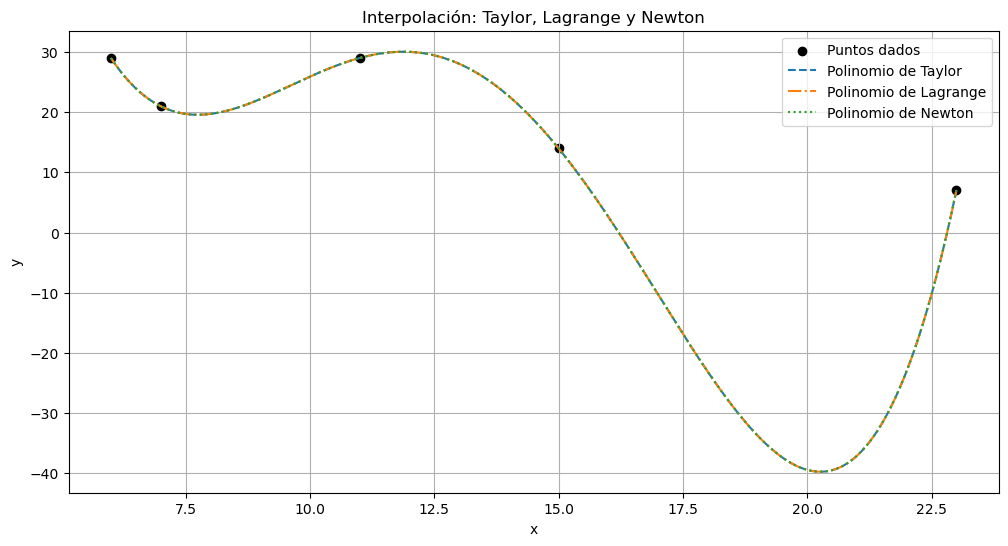


--- Forma explícita de cada polinomio ---

Polinomio de Taylor:
y = 448.122x^0 + -158.811x^1 + 20.855x^2 + -1.133x^3 + 0.021x^4

Polinomio de Lagrange:
y = 29.0*(x - 7.0)/(-1.0)*(x - 11.0)/(-5.0)*(x - 15.0)/(-9.0)*(x - 23.0)/(-17.0) + 21.0*(x - 6.0)/(1.0)*(x - 11.0)/(-4.0)*(x - 15.0)/(-8.0)*(x - 23.0)/(-16.0) + 29.0*(x - 6.0)/(5.0)*(x - 7.0)/(4.0)*(x - 15.0)/(-4.0)*(x - 23.0)/(-12.0) + 14.0*(x - 6.0)/(9.0)*(x - 7.0)/(8.0)*(x - 11.0)/(4.0)*(x - 23.0)/(-8.0) + 7.0*(x - 6.0)/(17.0)*(x - 7.0)/(16.0)*(x - 11.0)/(12.0)*(x - 15.0)/(8.0)

Polinomio de Newton:
y = 29.000 + -8.000*(x - 6.0) + 2.000*(x - 6.0)*(x - 7.0) + -0.302*(x - 6.0)*(x - 7.0)*(x - 11.0) + 0.021*(x - 6.0)*(x - 7.0)*(x - 11.0)*(x - 15.0)
Taylor:   f(5.0) = 47.18014705882352
Lagrange: f(5.0) = 47.18014705882352
Newton:   f(5.0) = 47.18014705882353
Taylor:   f(12.0) = 30.021139705881694
Lagrange: f(12.0) = 30.02113970588235
Newton:   f(12.0) = 30.021139705882355
Taylor:   f(21.0) = -37.08455882352882
Lagrange: f(21.0) = -37.084

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# enter points
num_points = int(input("How many points do you have? "))

points_x = []
points_y = []

for idx in range(num_points):
    x_val = float(input(f"Enter the value of x{idx}: "))
    y_val = float(input(f"Enter the value of y{idx}: "))
    points_x.append(x_val)
    points_y.append(y_val)

# domain for plotting
min_x, max_x = min(points_x), max(points_x)
domain_x = np.linspace(min_x, max_x, 500)

# TAYLOR POLYNOMIAL
def taylor_polynomial(x_list, y_list):
    n = len(x_list)
    matrix = [[x_list[i]**j for j in range(n)] for i in range(n)]
    matrix = np.array(matrix, dtype=float)
    b_vector = np.array(y_list, dtype=float)
    coefficients = np.linalg.solve(matrix, b_vector)  # monomial-basis coefficients

    def evaluate(x_val):
        return sum(coefficients[i] * x_val**i for i in range(n))

    expression = "y = " + " + ".join([f"{coefficients[i]:.3f}x^{i}" for i in range(n)])
    return evaluate, expression

# LAGRANGE POLYNOMIAL
def lagrange_polynomial(x_list, y_list):
    n = len(x_list)
    def evaluate(x_val):
        total = 0
        for i in range(n):
            term = y_list[i]
            for j in range(n):
                if i != j:
                    term *= (x_val - x_list[j]) / (x_list[i] - x_list[j])
            total += term
        return total

    expression = "y = " + " + ".join([
        f"{y_list[i]}*" + "*".join([f'(x - {x_list[j]})/({x_list[i] - x_list[j]})' for j in range(n) if i != j])
        for i in range(n)
    ])
    return evaluate, expression

# NEWTON POLYNOMIAL
def newton_polynomial(x_list, y_list):
    n = len(x_list)
    coefficients = [0] * n
    differences = [yi for yi in y_list]

    for j in range(n):
        coefficients[j] = differences[0]
        for i in range(n - j - 1):
            differences[i] = (differences[i+1] - differences[i]) / (x_list[i + j + 1] - x_list[i])

    def evaluate(x_val):
        result = coefficients[0]
        for i in range(1, n):
            product = coefficients[i]
            for j in range(i):
                product *= (x_val - x_list[j])
            result += product
        return result

    expression = f"y = {coefficients[0]:.3f}"
    for i in range(1, n):
        term = f"{coefficients[i]:.3f}"
        for j in range(i):
            term += f"*(x - {x_list[j]})"
        expression += " + " + term
    return evaluate, expression

# build functions and expressions
eval_taylor, expr_taylor = taylor_polynomial(points_x, points_y)
eval_lagrange, expr_lagrange = lagrange_polynomial(points_x, points_y)
eval_newton, expr_newton = newton_polynomial(points_x, points_y)

# evaluate over the domain
values_taylor = [eval_taylor(xi) for xi in domain_x]
values_lagrange = [eval_lagrange(xi) for xi in domain_x]
values_newton = [eval_newton(xi) for xi in domain_x]

# plot
plt.figure(figsize=(12, 6))
plt.scatter(points_x, points_y, color='black', label='Given points')

plt.plot(domain_x, values_taylor, label='Taylor polynomial', linestyle='--')
plt.plot(domain_x, values_lagrange, label='Lagrange polynomial', linestyle='-.')
plt.plot(domain_x, values_newton, label='Newton polynomial', linestyle=':')

plt.title("Interpolation: Taylor, Lagrange, and Newton")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# show the explicit expressions
print("\n--- Explicit form of each polynomial ---\n")
print("Taylor polynomial:")
print(expr_taylor)
print("\nLagrange polynomial:")
print(expr_lagrange)
print("\nNewton polynomial:")
print(expr_newton)

# optional point evaluation
while True:
    answer = input("\nDo you want to evaluate a specific point? (y/n): ").lower()
    if answer != "y":
        break
    x_eval = float(input("Enter the value of x: "))
    print(f"Taylor:   f({x_eval}) = {eval_taylor(x_eval)}")
    print(f"Lagrange: f({x_eval}) = {eval_lagrange(x_eval)}")
    print(f"Newton:   f({x_eval}) = {eval_newton(x_eval)}")


**2.** Given the following tabulated dataset:

| x   | y    |
|-----|------|
| 0.4 | 800  |
| 0.8 | 975  |
| 1.2 | 1501 |
| 1.6 | 1951 |
| 2   | 2902 |
| 2.3 | 3605 |

A) Determine and show, in the Taylor, Lagrange, and Newton bases, the polynomial that passes through all the tabulated data.

In [22]:
import numpy as np

# Ask for the number of points and the x and y values
num_points = int(input("How many points do you have? "))

points_x = []
points_y = []

for idx in range(num_points):
    x_val = float(input(f"Enter the value of x{idx}: "))
    y_val = float(input(f"Enter the value of y{idx}: "))
    points_x.append(x_val)
    points_y.append(y_val)

# ---------------- TAYLOR POLYNOMIAL ----------------
def taylor_polynomial(points_x, points_y):
    matrix = [[points_x[i]**j for j in range(num_points)] for i in range(num_points)]
    matrix = np.array(matrix, dtype=float)
    vector = np.array(points_y, dtype=float)
    coefficients = np.linalg.solve(matrix, vector)
    0.4
    expression = "y = " + " + ".join([f"{coefficients[i]:.3f} * x^{i}" for i in range(num_points)])
    return expression

# ---------------- LAGRANGE POLYNOMIAL ----------------
def lagrange_polynomial(points_x, points_y):
    polynomial_terms = []
    for i in range(num_points):
        term = f"{points_y[i]:.3f}"
        for j in range(num_points):
            if i != j:
                numerator = f"(x - {points_x[j]:.3f})"
                denominator = f"({points_x[i] - points_x[j]:.3f})"
                term += f" * {numerator}/{denominator}"
        polynomial_terms.append(term)
    expression = "y = " + " + ".join(polynomial_terms)
    return expression

# ---------------- NEWTON POLYNOMIAL ----------------
def newton_polynomial(points_x, points_y):
    coefficients = [0] * num_points
    difference_table = points_y.copy()

    for j in range(num_points):
        coefficients[j] = difference_table[0]
        for i in range(num_points - j - 1):
            numerator = difference_table[i + 1] - difference_table[i]
            denominator = points_x[i + j + 1] - points_x[i]
            difference_table[i] = numerator / denominator

    expression = f"y = {coefficients[0]:.3f}"
    for i in range(1, num_points):
        term = f"{coefficients[i]:.3f}"
        for j in range(i):
            term += f" * (x - {points_x[j]:.3f})"
        expression += " + " + term
    return expression

# ---------------- Show the results ----------------
print("\n--- Polynomials passing through the given points ---\n")

print("Taylor polynomial:")
print(taylor_polynomial(points_x, points_y))

print("\nLagrange polynomial:")
print(lagrange_polynomial(points_x, points_y))

print("\nNewton polynomial:")
print(newton_polynomial(points_x, points_y))



--- Polinomios que atraviesan los puntos dados ---

Polinomio de Taylor:
y = 4744.498 * x^0 + -21408.219 * x^1 + 40309.225 * x^2 + -33519.187 * x^3 + 13047.680 * x^4 + -1902.261 * x^5

Polinomio de Lagrange:
y = 800.000 * (x - 0.800)/(-0.400) * (x - 1.200)/(-0.800) * (x - 1.600)/(-1.200) * (x - 2.000)/(-1.600) * (x - 2.300)/(-1.900) + 975.000 * (x - 0.400)/(0.400) * (x - 1.200)/(-0.400) * (x - 1.600)/(-0.800) * (x - 2.000)/(-1.200) * (x - 2.300)/(-1.500) + 1501.000 * (x - 0.400)/(0.800) * (x - 0.800)/(0.400) * (x - 1.600)/(-0.400) * (x - 2.000)/(-0.800) * (x - 2.300)/(-1.100) + 1951.000 * (x - 0.400)/(1.200) * (x - 0.800)/(0.800) * (x - 1.200)/(0.400) * (x - 2.000)/(-0.400) * (x - 2.300)/(-0.700) + 2902.000 * (x - 0.400)/(1.600) * (x - 0.800)/(1.200) * (x - 1.200)/(0.800) * (x - 1.600)/(0.400) * (x - 2.300)/(-0.300) + 3605.000 * (x - 0.400)/(1.900) * (x - 0.800)/(1.500) * (x - 1.200)/(1.100) * (x - 1.600)/(0.700) * (x - 2.000)/(0.300)

Polinomio de Newton:
y = 800.000 + 437.500 * (x -

B) Choose a polynomial determined via least squares. Show the correlation coefficient of the polynomial that best describes the trend in the data, and show the resulting polynomial.


P(x) = 747.38709 + -97.55562 * x^1 + 512.37808 * x^2 + 31.61750 * x^3


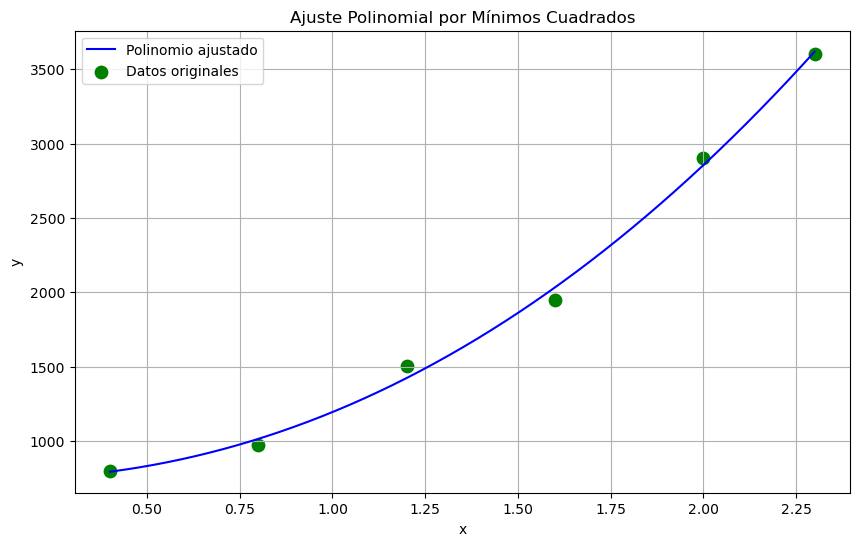


Coeficiente de correlación (R²): 0.99727


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Original data (x, y)
x_vals = [0.4, 0.8, 1.2, 1.6, 2, 2.3]
y_vals = [800, 975, 1501, 1951, 2902, 3605]

num_points = len(x_vals)
desired_degree = int(input("Degree of the polynomial: "))
poly_size = desired_degree + 1  # includes x^0 through x^n

# Build the augmented matrix of the normal-equations system
system_matrix = np.zeros((poly_size, poly_size + 1))

for row in range(poly_size):
    for col in range(poly_size):
        power_sum = sum(x_vals[k] ** (row + col) for k in range(num_points))
        system_matrix[row][col] = power_sum

    product_sum = sum(y_vals[k] * (x_vals[k] ** row) for k in range(num_points))
    system_matrix[row][poly_size] = product_sum

# Helper to swap rows when the pivot is zero
def swap_rows(matrix, row_a, row_b):
    matrix = matrix.copy()
    temp_row = matrix[row_b].copy()
    matrix[row_b] = matrix[row_a]
    matrix[row_a] = temp_row
    return matrix

# Gauss-Jordan elimination to solve the system
def solve_gauss_jordan(matrix, size):
    for pivot in range(size):
        for row in range(size):
            if pivot == row:
                continue  # skip the pivot row itself
            else:
                if matrix[pivot][pivot] == 0:
                    matrix = swap_rows(matrix, pivot, pivot + 1)
                factor = matrix[row][pivot] / matrix[pivot][pivot]
                for col in range(size + 1):
                    matrix[row][col] -= factor * matrix[pivot][col]

    # Normalize the diagonal
    for row in range(size):
        matrix[row][size] /= matrix[row][row]
        matrix[row][row] = 1
    return matrix

# Solve the system
system_matrix = solve_gauss_jordan(system_matrix, poly_size)

# Extract the fitted polynomial's coefficients
fit_coefficients = np.zeros(poly_size)
for i in range(poly_size):
    fit_coefficients[i] = system_matrix[i][poly_size]

# Function representing the fitted polynomial
def evaluate_polynomial(x, coefficients):
    return sum(coefficients[i] * (x ** i) for i in range(len(coefficients)))

# Show the symbolic form of the polynomial
poly_expression = " + ".join(
    f"{fit_coefficients[i]:.5f} * x^{i}" if i > 0 else f"{fit_coefficients[i]:.5f}"
    for i in range(len(fit_coefficients))
)
print(f"\nP(x) = {poly_expression}")

# Plot the polynomial together with the original points
x_plot = np.linspace(min(x_vals), max(x_vals), 500)
y_plot = [evaluate_polynomial(xi, fit_coefficients) for xi in x_plot]

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, color='blue', label="Fitted polynomial")
plt.scatter(x_vals, y_vals, color="green", s=80, label="Original data")
plt.title("Polynomial Fit via Least Squares")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Compute R²
computed_y = [evaluate_polynomial(xi, fit_coefficients) for xi in x_vals]
mean_y = np.mean(y_vals)
total_sum = sum((yi - mean_y) ** 2 for yi in y_vals)
residual_sum = sum((yi - y_hat) ** 2 for yi, y_hat in zip(y_vals, computed_y))
r_squared = 1 - (residual_sum / total_sum)

print(f"\nCorrelation coefficient (R²): {r_squared:.5f}")


C) Fit an exponential curve via least squares and show the correlation. Show the resulting function.

Ajuste exponencial: y = 530.823 * e^(0.816x)
Coeficiente de correlación R² = 0.99965


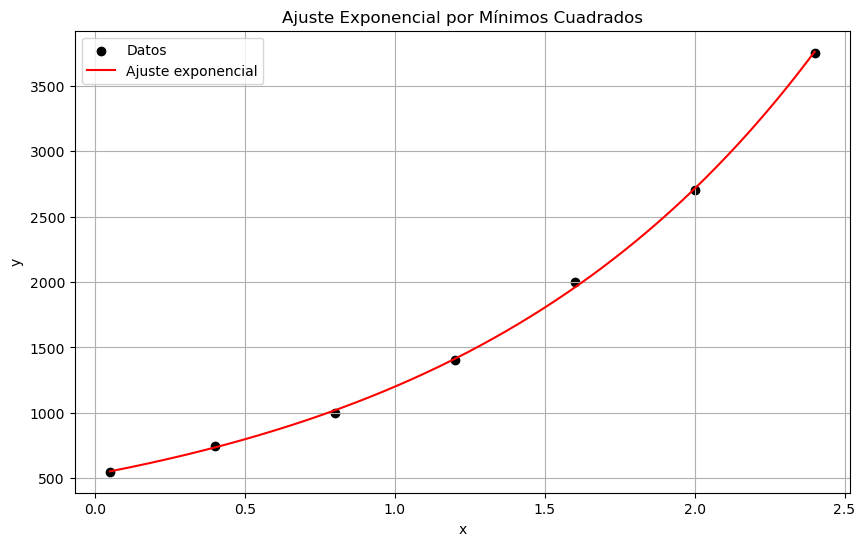

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([0.05, 0.4, 0.8, 1.2, 1.6, 2, 2.4])
y = np.array([550, 750, 1000, 1400, 2000, 2700, 3750])

# Logarithmic transformation
ln_y = np.log(y)
n = len(x)

# Least-squares sums
Sx = np.sum(x)
Sy = np.sum(ln_y)
Sxx = np.sum(x**2)
Sxy = np.sum(x * ln_y)

# Coefficient computation
B = (n * Sxy - Sx * Sy) / (n * Sxx - Sx**2)
ln_A = (Sy - B * Sx) / n
A = np.exp(ln_A)

# Fitted function
def f_exp(x): return A * np.exp(B * x)

# Evaluation
y_fit = f_exp(x)

# R² computation
mean_y = np.mean(y)
St = np.sum((y - mean_y)**2)
Sr = np.sum((y - y_fit)**2)
R2 = 1 - (Sr / St)

# Results
print("Exponential fit: y = {:.3f} * e^({:.3f}x)".format(A, B))
print("Correlation coefficient R² = {:.5f}".format(R2))

# Plot
x_plot = np.linspace(min(x), max(x), 500)
y_plot = f_exp(x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label="Data")
plt.plot(x_plot, y_plot, color='red', label=f"Exponential fit")
plt.title("Exponential Fit via Least Squares")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


D) Fit a power-law curve via least squares and show the correlation. Show the resulting function.

Ajuste de potencias: y = 1610.276 * x^0.457
Coeficiente de correlación R² = 0.69139


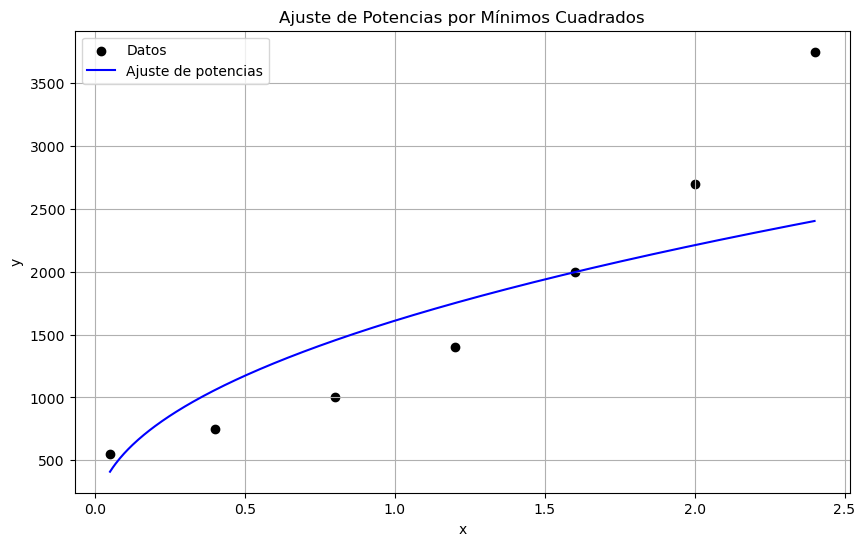

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([0.05, 0.4, 0.8, 1.2, 1.6, 2, 2.4])
y = np.array([550, 750, 1000, 1400, 2000, 2700, 3750])

# Logarithmic transformation for the power-law fit
ln_x = np.log(x)
ln_y = np.log(y)
n = len(x)

# Least-squares sums
Sx = np.sum(ln_x)
Sy = np.sum(ln_y)
Sxx = np.sum(ln_x**2)
Sxy = np.sum(ln_x * ln_y)

# Coefficient computation
B = (n * Sxy - Sx * Sy) / (n * Sxx - Sx**2)
ln_A = (Sy - B * Sx) / n
A = np.exp(ln_A)

# Fitted function
def f_pow(x): return A * x**B

# Evaluation
y_fit = f_pow(x)

# R² computation
mean_y = np.mean(y)
St = np.sum((y - mean_y)**2)
Sr = np.sum((y - y_fit)**2)
R2 = 1 - (Sr / St)

# Results
print("Power-law fit: y = {:.3f} * x^{:.3f}".format(A, B))
print("Correlation coefficient R² = {:.5f}".format(R2))

# Plot
x_plot = np.linspace(min(x), max(x), 500)
y_plot = f_pow(x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label="Data")
plt.plot(x_plot, y_plot, color='blue', label=f"Power-law fit")
plt.title("Power-Law Fit via Least Squares")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


**3.** Given the tabulated data:

| x   | y   |
|-----|-----|
| 0.5 | 1.1 |
| 0.8 | 2.4 |
| 1.5 | 5.3 |
| 2.5 | 7.6 |
| 4   | 8.9 |

Consider a function of the form $Y(x) = \dfrac{kx^2}{c+x^2}$, where $k$ and $c$ are parameters to be determined. Show a linearizing transformation of this expression and use linear regression to find the values of these parameters. What is the value of Y(2)?

### Linearizing the function $ Y(x) = \dfrac{kx^2}{c + x^2} $

We want to find a way to **linearize** the function:

$
Y(x) = \frac{kx^2}{c + x^2}
$

Our goal is to transform it algebraically into an expression with the form of a line:

$
u = a + b \cdot v
$

### Step 1: Divide both sides by \( x^2 \)

$
\frac{Y}{x^2} = \frac{k}{c + x^2}
$

### Step 2: Take the reciprocal of both sides

$
\frac{x^2}{Y} = \frac{c + x^2}{k}
$

### Step 3: Separate terms

$
\frac{x^2}{Y} = \frac{c}{k} + \frac{x^2}{k}
$

### Step 4: Define variables for the linear regression

Define:

- $ u = \dfrac{x^2}{Y} $
- $ v = x^2 $

so the equation becomes:

$
u = \frac{c}{k} + \frac{1}{k} \cdot v
$

which has the linear form:

$
u = a + b \cdot v
$

where:

- $ a = \dfrac{c}{k} $
- $ b = \dfrac{1}{k} $

### Step 5: Recover the original parameters

Once $a$ and $b$ are found via linear regression, the original parameters can be recovered as:

$
k = \frac{1}{b}, \quad c = \frac{a}{b}
$

Modelo lineal (transformado): u = 0.20137 + 0.09971 * v
Modelo original: Y(x) = 10.029 * x^2 / (2.019 + x^2)
Coeficiente de correlación R² = 0.99999

El valor de Y(2) ≈ 6.6642


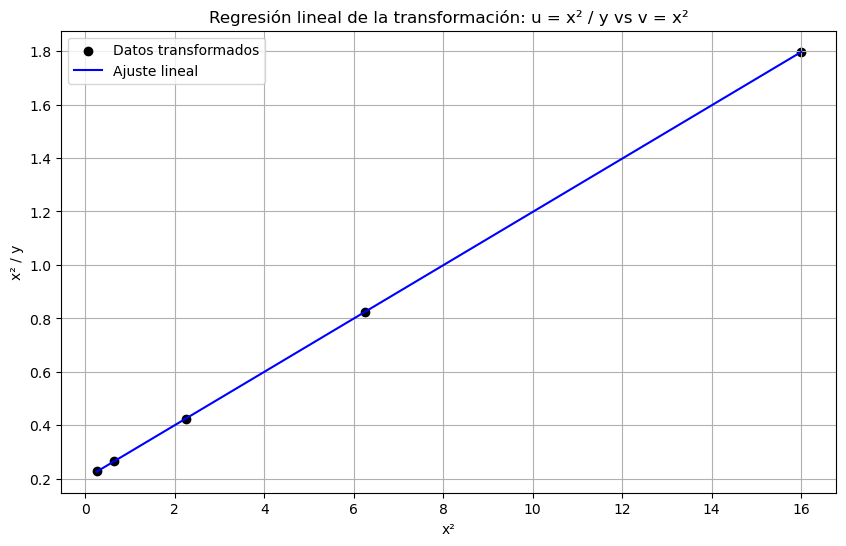

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Original data
x_vals = np.array([0.5, 0.8, 1.5, 2.5, 4])
y_vals = np.array([1.1, 2.4, 5.3, 7.6, 8.9])
n = len(x_vals)

# Linearizing transformation: u = x^2 / y, v = x^2
v_vals = x_vals**2
u_vals = v_vals / y_vals

# Sums for linear regression
Sv = np.sum(v_vals)
Su = np.sum(u_vals)
Svv = np.sum(v_vals**2)
Svu = np.sum(v_vals * u_vals)

# Coefficients of the line: u = a + b*v
b = (n * Svu - Sv * Su) / (n * Svv - Sv**2)
a = (Su - b * Sv) / n

# Recover k and c
k = 1 / b
c = a / b

print("Linear (transformed) model: u = {:.5f} + {:.5f} * v".format(a, b))
print("Original model: Y(x) = {:.3f} * x^2 / ({:.3f} + x^2)".format(k, c))

# Compute R²
u_pred = a + b * v_vals
mean_u = np.mean(u_vals)
St = np.sum((u_vals - mean_u)**2)
Sr = np.sum((u_vals - u_pred)**2)
R2 = 1 - (Sr / St)
print("Correlation coefficient R² = {:.5f}".format(R2))

# Value of Y(2)
x_val = 2
y_val_2 = (k * x_val**2) / (c + x_val**2)
print(f"\nY(2) ≈ {y_val_2:.4f}")

# Plot the linearized fit
v_plot = np.linspace(min(v_vals), max(v_vals), 500)
u_plot = a + b * v_plot

plt.figure(figsize=(10, 6))
plt.scatter(v_vals, u_vals, color='black', label="Transformed data")
plt.plot(v_plot, u_plot, color='blue', label="Linear fit")
plt.title("Linear regression of the transformation: u = x² / y vs v = x²")
plt.xlabel("x²")
plt.ylabel("x² / y")
plt.legend()
plt.grid(True)
plt.show()


**4.** The region from sea level up to approximately 36,000 ft is called the \"troposphere\", where standard atmospheric temperature varies linearly with altitude.

a) Describe the true variation T = T(h), given that the temperature at sea level (h = 0 ft) is 518.69 °R and 447.43 °R at an altitude of 20,000 ft.

b) Air pressure and the speed of sound vary with altitude in the troposphere. The following table lists several measurements of how these quantities vary with altitude.

| Altitude: h (ft) | Pressure: P (psi) | Speed of sound: V (ft/s) |
|-------------------|--------------------|---------------------------|
| 0                 | 14.7               | 1116.4                    |
| 5000              | 12.2               | 1097.1                    |
| 10000             | 10.1               | 1077.4                    |
| 20000             | 6.76               | 1036.9                    |
| 30000             | 4.37               | 994.85                    |
| 36000             | 3.31               | 968.75                    |

An interpolating polynomial is needed to estimate p at different altitudes. Reorder the data points if necessary, and compute the full table of divided differences.

c) Determine the lowest-degree Newton interpolating polynomial $f_n(h)$ suitable for interpolating \"$p$\". Do not choose the full 5th-degree polynomial, i.e. $n < 5$.

d) Repeat the exercise using a least-squares fit instead. (Consider whether the best result is a polynomial or a linearizable nonlinear function, and show the best result along with its correlation coefficient.)

e) Plot the data points $(h_i, p_i)$, $i = 0,1,2,3,4,5$, together with the interpolating polynomial $p = f_n(h)$.

f) Use $f_n(25{,}000)$ to estimate atmospheric pressure in the troposphere at an altitude of 25,000 ft, i.e. $f(25{,}000)$ where $p = f(h)$ is the relationship between the two. The theoretical function relating $p$ (in psi) and $h$ (in ft) is:

$$
p = f(h) = p(0) \left(\frac{T(h)}{T(0)}\right)^{-g/(aR)}
$$

where:

$g$ = gravitational constant at sea level (32.17 ft/s²)

$R$ = specific gas constant for air (1718 ft·lb/slug·R)

$a$ = temperature lapse rate in the troposphere, i.e. the slope of the linear function $T = T(h)$.

$p(0)$ = atmospheric pressure at sea level, psi

$T(0)$ = atmospheric temperature at sea level, R

g) Plot the function $p = f(h)$ on the same graph as the data $(h_i, p_i)$, together with the interpolating polynomial from part c), $p = f_n(h)$.

h) Compute the true error $f(25{,}000) - f_n(25{,}000)$.

### Part a) — Temperature Variation in the Troposphere

The region from sea level up to approximately 36,000 ft is known as the troposphere, where standard atmospheric temperature varies linearly with altitude.

Given:

- At sea level ($h = 0$ ft), the temperature is $T(0) = 518.69\ ^\circ R$
- At an altitude of $h = 20{,}000$ ft, the temperature is $T(20000) = 447.43\ ^\circ R$

### Approach

1. Assume the temperature varies linearly with altitude:

$$
T(h) = a + b \cdot h
$$

2. Determine the coefficients $a$ and $b$ via least-squares linear regression.

3. Find the explicit expression for $T(h)$ and, optionally, use it to estimate the temperature at any altitude within the troposphere (e.g., at 36,000 ft).

Función T(h) = 518.6900 + -0.003563 * h


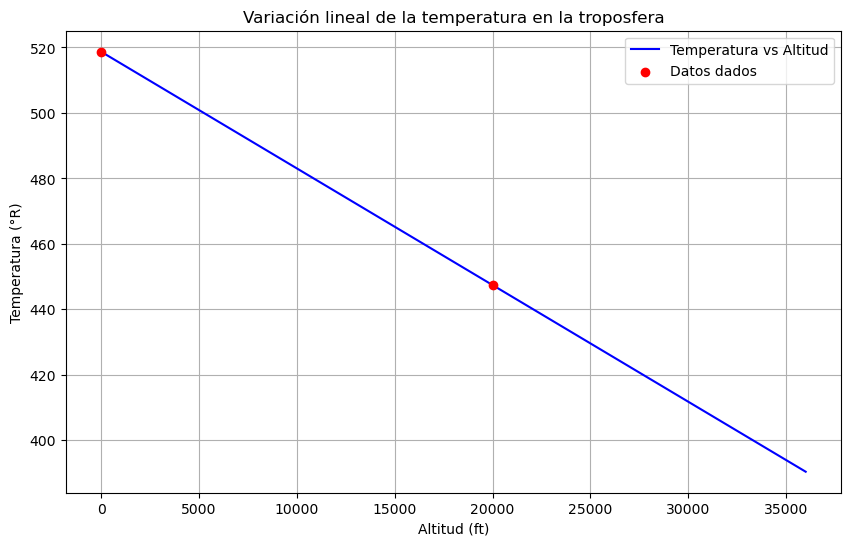

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Altitude (h) in feet and temperature (T) in °R
altitudes = np.array([0, 20000])
temperatures = np.array([518.69, 447.43])
n = len(altitudes)

# Sums needed for the linear least-squares fit
Sx = np.sum(altitudes)
Sy = np.sum(temperatures)
Sxx = np.sum(altitudes**2)
Sxy = np.sum(altitudes * temperatures)

# Coefficients of the line T(h) = a + b*h
b = (n * Sxy - Sx * Sy) / (n * Sxx - Sx**2)
a = (Sy - b * Sx) / n

# Show the equation
print(f"Function T(h) = {a:.4f} + {b:.6f} * h")

# Plot the line
h_vals = np.linspace(0, 36000, 500)
T_vals = a + b * h_vals

plt.figure(figsize=(10,6))
plt.plot(h_vals, T_vals, label="Temperature vs. Altitude", color='blue')
plt.scatter(altitudes, temperatures, color='red', label="Given data", zorder=5)
plt.title("Linear variation of temperature in the troposphere")
plt.xlabel("Altitude (ft)")
plt.ylabel("Temperature (°R)")
plt.grid(True)
plt.legend()
plt.show()


**Part b)**

In [35]:
import numpy as np

# Altitude (h) and pressure (P) data
altitudes = np.array([0, 5000, 10000, 20000, 30000, 36000], dtype=float)
pressures = np.array([14.7, 12.2, 10.1, 6.76, 4.37, 3.31], dtype=float)

# Number of points
n = len(altitudes)

# Initialize the divided-differences table
diff_table = np.zeros((n, n))
diff_table[:, 0] = pressures

# Compute the divided differences
for j in range(1, n):
    for i in range(n - j):
        diff_table[i][j] = (diff_table[i + 1][j - 1] - diff_table[i][j - 1]) / (altitudes[i + j] - altitudes[i])

# Show the full divided-differences table
print("Newton divided-differences table:\n")
for i in range(n):
    row = [f"{diff_table[i, j]:.6f}" if j <= n - i - 1 else "" for j in range(n)]
    print(f"Row {i}: {row}")

# Symbolic construction of the Newton polynomial
def newton_polynomial(x, x_vals, table):
    n = len(x_vals)
    result = table[0, 0]
    for i in range(1, n):
        term = table[0, i]
        for j in range(i):
            term *= (x - x_vals[j])
        result += term
    return result

# Show the symbolic form of the polynomial
print("\nNewton polynomial:")
expression = f"P(h) = {diff_table[0, 0]:.6f}"
for i in range(1, n):
    term = f"{diff_table[0, i]:+.6f}"
    for j in range(i):
        term += f"*(h - {altitudes[j]:.0f})"
    expression += " " + term
print(expression)

# Example: estimate pressure at 15000 ft
h_target = 15000
p_estimate = newton_polynomial(h_target, altitudes, diff_table)
print(f"\nPressure estimate at {h_target} ft: P({h_target}) ≈ {p_estimate:.4f} psi")


Tabla de diferencias divididas (Newton):

Fila 0: ['14.700000', '-0.000500', '0.000000', '-0.000000', '0.000000', '-0.000000']
Fila 1: ['12.200000', '-0.000420', '0.000000', '-0.000000', '0.000000', '']
Fila 2: ['10.100000', '-0.000334', '0.000000', '-0.000000', '', '']
Fila 3: ['6.760000', '-0.000239', '0.000000', '', '', '']
Fila 4: ['4.370000', '-0.000177', '', '', '', '']
Fila 5: ['3.310000', '', '', '', '', '']

Polinomio de Newton:
P(h) = 14.700000 -0.000500*(h - 0) +0.000000*(h - 0)*(h - 5000) -0.000000*(h - 0)*(h - 5000)*(h - 10000) +0.000000*(h - 0)*(h - 5000)*(h - 10000)*(h - 20000) -0.000000*(h - 0)*(h - 5000)*(h - 10000)*(h - 20000)*(h - 30000)

Estimación de presión a 15000 pies: P(15000) ≈ 8.3022 PSI


**Part c)**

In [36]:
import numpy as np

# Data
altitudes = np.array([0, 5000, 10000, 20000, 30000, 36000], dtype=float)
pressures = np.array([14.7, 12.2, 10.1, 6.76, 4.37, 3.31], dtype=float)
n = len(altitudes)

# Initialize the divided-differences table
diff_table = np.zeros((n, n))
diff_table[:, 0] = pressures

# Compute the divided differences
for j in range(1, n):
    for i in range(n - j):
        diff_table[i][j] = (diff_table[i + 1][j - 1] - diff_table[i][j - 1]) / (altitudes[i + j] - altitudes[i])

# Show the divided-differences table
print("Divided-differences table:\n")
for i in range(n):
    row = [f"{diff_table[i, j]:.6f}" if j <= n - i - 1 else "" for j in range(n)]
    print(f"Row {i}: {row}")

# Find the lowest suitable degree: look for where the differences stabilize / become small
print("\nEvaluating the lowest suitable degree:")
tolerance = 0.001  # cutoff criterion (adjustable)
suitable_degree = 0
for j in range(1, n):
    max_diff = max(abs(diff_table[i][j]) for i in range(n - j))
    print(f"Order-{j} differences: max = {max_diff:.6f}")
    if max_diff < tolerance:
        suitable_degree = j
        break

if suitable_degree == 0:
    print("\nNo sufficiently small difference was found; the full-degree polynomial may be needed.")
else:
    print(f"\nThe lowest suitable degree for interpolating the pressure is: {suitable_degree}")


Tabla de diferencias divididas:

Fila 0: ['14.700000', '-0.000500', '0.000000', '-0.000000', '0.000000', '-0.000000']
Fila 1: ['12.200000', '-0.000420', '0.000000', '-0.000000', '0.000000', '']
Fila 2: ['10.100000', '-0.000334', '0.000000', '-0.000000', '', '']
Fila 3: ['6.760000', '-0.000239', '0.000000', '', '', '']
Fila 4: ['4.370000', '-0.000177', '', '', '', '']
Fila 5: ['3.310000', '', '', '', '', '']

Evaluación del menor grado adecuado:
Diferencias de orden 1: máx = 0.000500

El menor grado adecuado para interpolar la presión es: 1


**Part d)**

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Data
h = np.array([0, 5000, 10000, 20000, 30000, 36000], dtype=float)
p = np.array([14.7, 12.2, 10.1, 6.76, 4.37, 3.31], dtype=float)
n = len(h)

# LINEAR fit: p = a + b*h
Sx = np.sum(h)
Sy = np.sum(p)
Sxx = np.sum(h**2)
Sxy = np.sum(h * p)

b_lin = (n * Sxy - Sx * Sy) / (n * Sxx - Sx**2)
a_lin = (Sy - b_lin * Sx) / n

def f_linear(x): return a_lin + b_lin * x
p_linear = f_linear(h)
St = np.sum((p - np.mean(p))**2)
Sr_lin = np.sum((p - p_linear)**2)
R2_lin = 1 - (Sr_lin / St)

# EXPONENTIAL fit: p = A * exp(B*h)
ln_p = np.log(p)
Sy_log = np.sum(ln_p)
Sxy_log = np.sum(h * ln_p)

b_exp = (n * Sxy_log - Sx * Sy_log) / (n * Sxx - Sx**2)
a_log_exp = (Sy_log - b_exp * Sx) / n
A_exp = np.exp(a_log_exp)

def f_exponential(x): return A_exp * np.exp(b_exp * x)
p_exp = f_exponential(h)
Sr_exp = np.sum((p - p_exp)**2)
R2_exp = 1 - (Sr_exp / St)

# POWER-LAW fit: p = A * h^B
# drop h = 0 (undefined in log)
h_pow = h[1:]
p_pow = p[1:]
ln_h = np.log(h_pow)
ln_p2 = np.log(p_pow)

Sx2 = np.sum(ln_h)
Sy2 = np.sum(ln_p2)
Sxx2 = np.sum(ln_h**2)
Sxy2 = np.sum(ln_h * ln_p2)

b_pow = (n-1) * Sxy2 - Sx2 * Sy2
b_pow /= (n-1) * Sxx2 - Sx2**2
a_log_pow = (Sy2 - b_pow * Sx2) / (n - 1)
A_pow = np.exp(a_log_pow)

def f_power(x): return A_pow * x**b_pow
p_pow_fit = f_power(h_pow)
St2 = np.sum((p_pow - np.mean(p_pow))**2)
Sr2 = np.sum((p_pow - p_pow_fit)**2)
R2_pow = 1 - (Sr2 / St2)

# Show models and R²
print("Linear model:      p(h) = {:.4f} + {:.6f}h   | R² = {:.5f}".format(a_lin, b_lin, R2_lin))
print("Exponential model:  p(h) = {:.4f} * exp({:.6f}h) | R² = {:.5f}".format(A_exp, b_exp, R2_exp))
print("Power-law model:    p(h) = {:.4f} * h^{:.6f}   | R² = {:.5f}".format(A_pow, b_pow, R2_pow))

# Comparison
candidates = {
    R2_lin: "linear",
    R2_exp: "exponential",
    R2_pow: "power-law"
}
best = candidates[max(candidates.keys())]
print(f"\nThe best-fitting model according to R² is: **{best.upper()}**")


Modelo lineal:       p(h) = 13.8245 + -0.000312h   | R² = 0.97699
Modelo exponencial:  p(h) = 15.0379 * exp(-0.000041h) | R² = 0.99821
Modelo potencia:     p(h) = 3405.0518 * h^-0.645624   | R² = 0.89571

El modelo que mejor se ajusta según R² es: **EXPONENCIAL**


**Part e)**

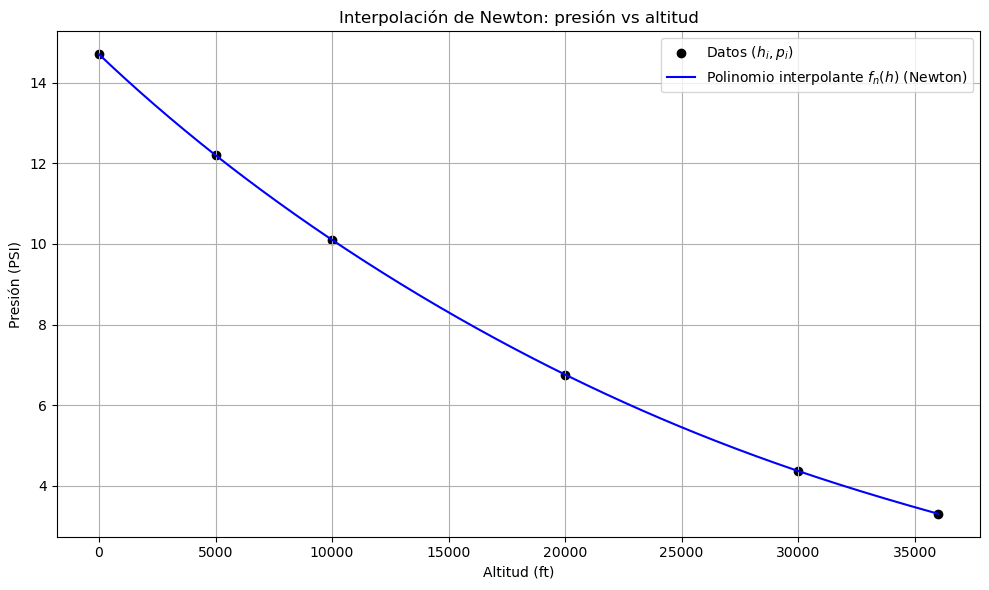

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Data
altitudes = np.array([0, 5000, 10000, 20000, 30000, 36000], dtype=float)
pressures = np.array([14.7, 12.2, 10.1, 6.76, 4.37, 3.31], dtype=float)
n = len(altitudes)

# Divided-differences table
diff_table = np.zeros((n, n))
diff_table[:, 0] = pressures

for j in range(1, n):
    for i in range(n - j):
        diff_table[i][j] = (diff_table[i + 1][j - 1] - diff_table[i][j - 1]) / (altitudes[i + j] - altitudes[i])

# Newton polynomial function
def newton_polynomial(x, x_vals, table):
    n = len(x_vals)
    result = table[0, 0]
    for i in range(1, n):
        term = table[0, i]
        for j in range(i):
            term *= (x - x_vals[j])
        result += term
    return result

# Evaluate the polynomial for plotting
h_plot = np.linspace(min(altitudes), max(altitudes), 500)
p_interp = [newton_polynomial(x, altitudes, diff_table) for x in h_plot]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(altitudes, pressures, color='black', label="Data $(h_i, p_i)$")
plt.plot(h_plot, p_interp, color='blue', label="Newton interpolating polynomial $f_n(h)$")
plt.xlabel("Altitude (ft)")
plt.ylabel("Pressure (psi)")
plt.title("Newton interpolation: pressure vs. altitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Part f) — Estimating the Pressure at 25,000 ft

Atmospheric pressure in the troposphere at an altitude of **25,000 ft** is estimated using two different approaches:

### 1. Numerical method: Newton polynomial interpolation

From the experimental altitude ($h$) and pressure ($p$) data, an **interpolating polynomial** $f_n(h)$ is built using **Newton's divided-differences method**. It is then evaluated at $h = 25{,}000$ ft to estimate:

$$
f_n(25000) \approx \hat{p}(25000)
$$

### 2. Theoretical atmospheric model

The theoretical relationship between pressure $p$ and altitude $h$ in the troposphere is:

$$
p(h) = p(0) \cdot \left( \frac{T(h)}{T(0)} \right)^{- \frac{g}{aR}}
$$

where:

- $ p(0) = 14.7\ \text{psi} $: pressure at sea level
- $ T(0) = 518.69\ ^\circ R $: temperature at sea level
- $ T(h)$: temperature at altitude $h$, given by $ T(h) = T(0) + a \cdot h $
- $ a = \dfrac{T(20000) - T(0)}{20000} $: temperature lapse rate (negative)
- $ T(20000) = 447.43\ ^\circ R $: temperature measured at 20,000 ft
- $ g = 32.17\ \text{ft/s}^2 $: acceleration due to gravity
- $R = 1718\ \text{ft·lb} / (\text{slug} \cdot {}^\circ\text{R})$: specific gas constant for air

Once $a$ is determined, $T(25000)$ is computed and used to estimate:

$$
p(25000) = 14.7 \cdot \left( \frac{T(25000)}{518.69} \right)^{- \frac{32.17}{a \cdot 1718}}
$$

### Comparison

Both the numerical and theoretical pressure estimates at 25,000 ft are compared, along with the difference between them.

In [42]:
import numpy as np

# DATA
h_data = np.array([0, 5000, 10000, 20000, 30000, 36000], dtype=float)
p_data = np.array([14.7, 12.2, 10.1, 6.76, 4.37, 3.31], dtype=float)

# NEWTON INTERPOLATION
n = len(h_data)
diff_table = np.zeros((n, n))
diff_table[:, 0] = p_data

for j in range(1, n):
    for i in range(n - j):
        diff_table[i][j] = (diff_table[i + 1][j - 1] - diff_table[i][j - 1]) / (h_data[i + j] - h_data[i])

def f_newton(x, x_vals, table):
    result = table[0, 0]
    for i in range(1, len(x_vals)):
        term = table[0, i]
        for j in range(i):
            term *= (x - x_vals[j])
        result += term
    return result

# Evaluate the interpolated pressure at 25000 ft
h_interp = 25000
p_interp = f_newton(h_interp, h_data, diff_table)
print(f"Interpolated pressure f_n(25000) ≈ {p_interp:.5f} psi")

# THEORETICAL FORMULA
p0 = 14.7      # pressure at sea level (psi)
T0 = 518.69    # temperature at sea level (°R)
T20000 = 447.43  # temperature at 20,000 ft (°R)

g = 32.17      # gravity (ft/s²)
R = 1718       # specific gas constant for air (ft-lb/slug-R)
a = (T20000 - T0) / 20000  # temperature lapse rate (°R/ft)

# Temperature at 25000 ft
T25000 = T0 + a * 25000

# Exponent
exponent = -g / (a * R)

# Theoretical pressure
p_theoretical = p0 * (T25000 / T0) ** exponent
print(f"Theoretical pressure at 25000 ft ≈ {p_theoretical:.5f} psi")

# Comparison
error = abs(p_interp - p_theoretical)
print(f"\nDifference between interpolation and theoretical model: {error:.5f} psi")


Presión interpolada f_n(25000) ≈ 5.45426 psi
Presión teórica a 25000 ft ≈ 5.46097 psi

Diferencia entre interpolación y modelo teórico: 0.00671 psi


**Part g)**

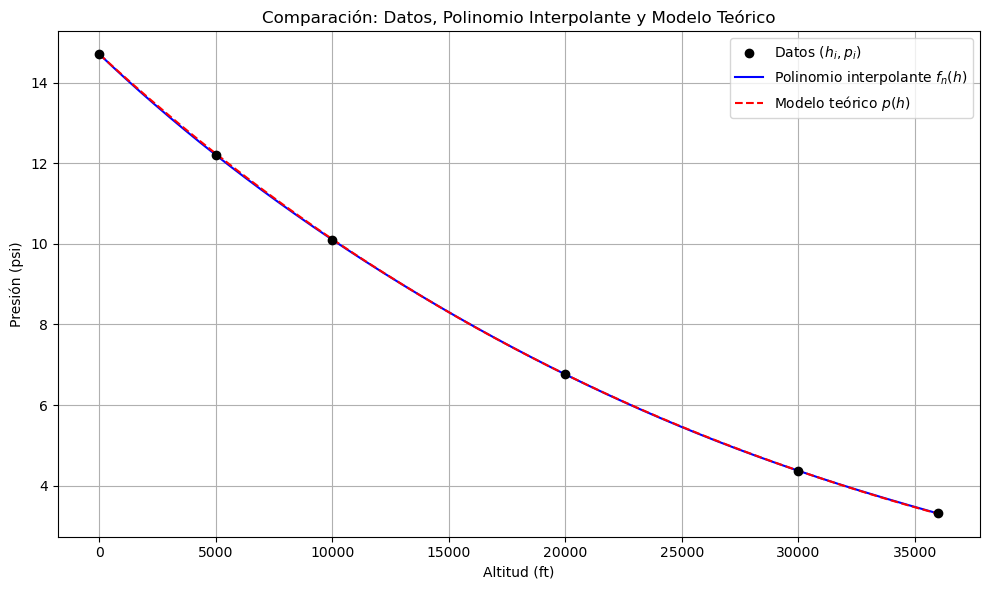

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Data (altitude in feet, pressure in psi)
h_data = np.array([0, 5000, 10000, 20000, 30000, 36000], dtype=float)
p_data = np.array([14.7, 12.2, 10.1, 6.76, 4.37, 3.31], dtype=float)

# Newton interpolation
n = len(h_data)
diff_table = np.zeros((n, n))
diff_table[:, 0] = p_data

for j in range(1, n):
    for i in range(n - j):
        diff_table[i][j] = (diff_table[i+1][j-1] - diff_table[i][j-1]) / (h_data[i + j] - h_data[i])

def f_newton(x, x_vals, table):
    result = table[0, 0]
    for i in range(1, len(x_vals)):
        term = table[0, i]
        for j in range(i):
            term *= (x - x_vals[j])
        result += term
    return result

# Theoretical function p(h)
def theoretical_function(h):
    # Physical data
    p0 = 14.7         # psi
    T0 = 518.69       # R
    T20000 = 447.43   # R
    g = 32.17         # ft/s²
    R = 1718          # ft·lb / slug·R

    a = (T20000 - T0) / 20000  # temperature lapse rate
    T_h = T0 + a * h
    exponent = -g / (a * R)

    return p0 * (T_h / T0)**exponent

# Build the domain for plotting
h_plot = np.linspace(0, 36000, 500)
p_interp = [f_newton(x, h_data, diff_table) for x in h_plot]
p_model = theoretical_function(h_plot)

# Combined plot
plt.figure(figsize=(10,6))
plt.scatter(h_data, p_data, color='black', label='Data $(h_i, p_i)$', zorder=5)
plt.plot(h_plot, p_interp, label='Interpolating polynomial $f_n(h)$', color='blue')
plt.plot(h_plot, p_model, label='Theoretical model $p(h)$', color='red', linestyle='--')

plt.xlabel("Altitude (ft)")
plt.ylabel("Pressure (psi)")
plt.title("Comparison: Data, Interpolating Polynomial, and Theoretical Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Part h)**

In [44]:
# Altitude to evaluate
h_eval = 25000

# Interpolated value
p_interp_25000 = f_newton(h_eval, h_data, diff_table)

# Theoretical model value
p_theoretical_25000 = theoretical_function(h_eval)

# Compute the true error
true_error = p_theoretical_25000 - p_interp_25000

print(f"\nInterpolated value f_n(25000) = {p_interp_25000:.6f} psi")
print(f"Theoretical value  f(25000)   = {p_theoretical_25000:.6f} psi")
print(f"\nTrue error = {true_error:.6f} psi")



Valor interpolado f_n(25000) = 5.454258 psi
Valor teórico     f(25000)   = 5.460972 psi

Error verdadero = 0.006713 psi
